# Inferencia estadística vs Aprendizaje de máquinas

Pía Amigo, 2026

### Parte 1: Ajuste de recta

(Adaptado de Viviana Acquaviva (2023))

**Objetivo:** Resolver el mismo problema con dos estrategias distintas y comparar sus resultados.

**Nombre(s):** Antonia Morales

In [51]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Parámetros para figuras de alta calidad
font = {'size': 12}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 150

np.random.seed(16)  # semilla fija para reproducibilidad

x = np.arange(10)
y = 2*x + 5 + np.random.randn(10)  # datos con scatter gaussiano
y = np.round(y, 1)

Los datos corresponden al movimiento de un auto con rapidez constante,
donde el eje $x$ es tiempo (en segundos) y el eje $y$ es distancia (en metros).

**Pregunta:** A partir de estos datos queremos predecir $d(t=12\text{ s})$.
Antes de escribir código: ¿cómo resolverías este problema? Describe tu estrategia con palabras.

**Tu respuesta:** Usando mis conocimientos de cinemática, intuiría que la función que mejor describe el movimiento del auto es aproximable a una función lineal, y usaría las observaciones conocidas y esta inferencia para tratar de llegar a una función que se ajuste a los datos existentes.

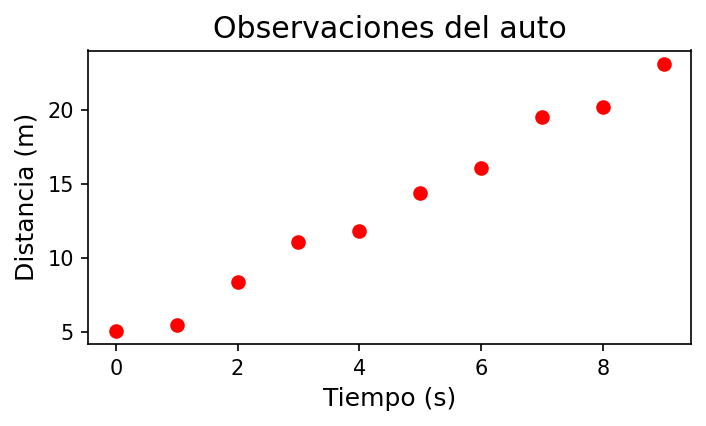

In [52]:
# Visualiza los datos
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='red')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Observaciones del auto')
plt.tight_layout()

## Parte 1: Inferencia estadística

Sabemos que la relación entre distancia y tiempo para un auto con rapidez constante es:
$$d = d_0 + v \cdot t$$

Este modelo tiene dos parámetros: $d_0$ (posición inicial) y $v$ (velocidad).
Nuestro objetivo es **encontrar los valores de $d_0$ y $v$** que mejor explican los datos.

### 1a. Búsqueda por grilla

Una estrategia es probar muchas combinaciones de parámetros y quedarse con la que
minimiza el **error cuadrático medio (MSE) (Mínimos cuadrados)**:

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(d^{\text{modelo}}_i - d^{\text{obs}}_i)^2$$

In [53]:
# Definimos la grilla de parámetros a explorar
m_range = np.linspace(0, 5, 100)   # posibles velocidades
b_range = np.linspace(0, 10, 100)  # posibles posiciones iniciales

best_mse = np.inf
bestm, bestb = 0, 0

mse_list = [] # lista para guardar los valores de MSE que se vayan calculando en el loop

# Completa el loop: para cada combinación (m, b),
# calcula el MSE y guarda los mejores parámetros
for m in m_range:
    for b in b_range:
        y_model = m * x + b
        mse = np.mean((y - y_model)**2)
        mse_list.append(mse)

        if mse == min(mse_list): # actualizando los valores óptimos para m y b
            # compara constantemente el valor actual de mse con los ya calculados
            # si es el valor más pequeño hasta ese momento, se dejan los m y b actual como los óptimos
            bestm = m
            bestb = b
            
    
mse_array = np.array(mse_list) # convertir la lista a array
mse_index = np.where(mse_array == min(mse_array))
best_mse = mse_array[mse_index][0]

print(f'Mejor pendiente (velocidad):   {bestm:.2f} m/s')
print(f'Mejor intercepto (pos. inicial): {bestb:.2f} m')
print(f'MSE mínimo: {best_mse:.2f}')
print(f'd(t=12): {bestm*12 + bestb:.2f}m')

Mejor pendiente (velocidad):   2.07 m/s
Mejor intercepto (pos. inicial): 4.24 m
MSE mínimo: 0.37
d(t=12): 29.09m


<details>
<summary>Ayuda</summary>

Dentro del loop calcula la predicción y el MSE:
```python
y_pred = m * x + b
mse = np.mean((y - y_pred)**2)
```
Luego comparas con `best_mse` y actualizas si encontraste algo mejor.
</details>

**¿Cuáles son los valores encontrados? ¿Son razonables físicamente?**
Con este modelo, ¿cuánto vale $d(t=12\text{ s})$?

- `bestm` = 2.07 m/s
- `bestb` = 4.24 m/s
- $d(t=12)$ = 29. 09 m

Son valores razonables físicamente si se tiene en cuenta la situación. Es esperable que el avance de un auto en la cantidad de tiempo dad se encuentre al menos en ese orden de magnitud.

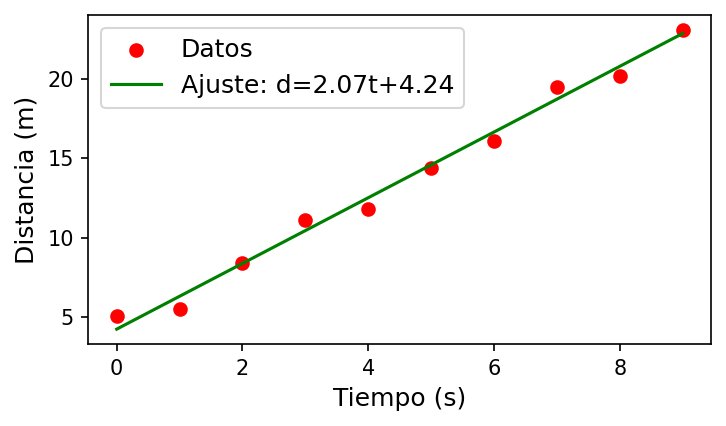

In [54]:
# Grafica los datos y la recta con los mejores parámetros
plt.figure(figsize=(5, 3))
plt.scatter(x, y, c='red', label='Datos')
plt.plot(x, bestm*x + bestb, c='g', label=f'Ajuste: d={bestm:.2f}t+{bestb:.2f}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.tight_layout()

### 1b. Ajuste con incertezas

En astronomía las mediciones siempre tienen incertezas.
Cuando las incluimos, los puntos más precisos (menor $\sigma_i$) deben tener
**más peso** en el ajuste. La función a minimizar se convierte en el $\chi^2$:

$$\chi^2 = \sum_{i=1}^{N} \frac{(d^{\text{modelo}}_i - d^{\text{obs}}_i)^2}{\sigma_i^2}$$

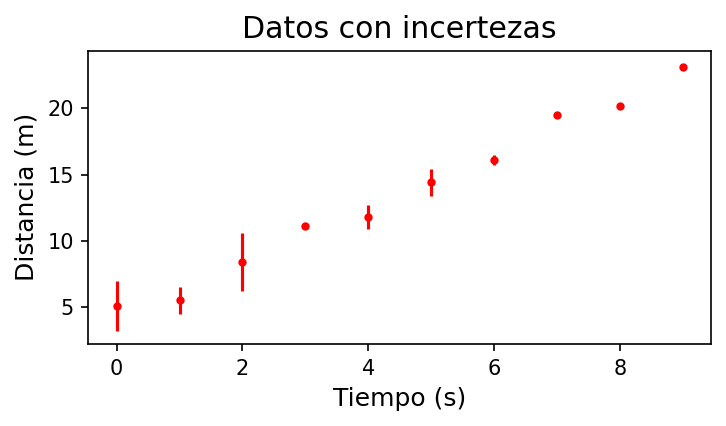

In [55]:
np.random.seed(10)
dy = np.random.randn(10) * np.sqrt(2)  # incertezas aleatorias

plt.figure(figsize=(5, 3))
plt.errorbar(x, y, np.abs(dy), marker='o', markersize=3, c='red', linestyle=' ')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Datos con incertezas')
plt.tight_layout()

In [56]:
# Encuentra los mejores parámetros usando chi2 en lugar de MSE
best_chi2 = np.inf
bestm_werr, bestb_werr = 0, 0

chi2_list = [] # lista para guardar los chi2

for m in m_range:
    for b in b_range:
        chi2 = np.sum(((y - (m*x + b)) / np.abs(dy))**2) 
        chi2_list.append(chi2)

        if chi2 == min(chi2_list): # comparación para encontrar los mejores m y b
            bestm_werr = m
            bestb_werr = b

print(f'Mejor pendiente (con incertezas):  {bestm_werr:.3f} m/s')
print(f'Mejor intercepto (con incertezas): {bestb_werr:.3f} m')

Mejor pendiente (con incertezas):  1.818 m/s
Mejor intercepto (con incertezas): 5.657 m


<details>
<summary> Ayuda</summary>

```python
chi2 = np.sum(((y - (m*x + b)) / np.abs(dy))**2)
```
</details>

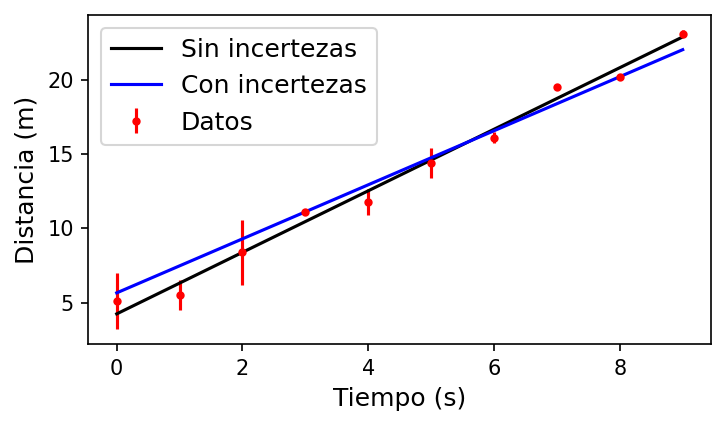

In [57]:
# Comparamos ambos ajustes
plt.figure(figsize=(5, 3))
plt.errorbar(x, y, np.abs(dy), marker='o', markersize=3, c='red', linestyle=' ', label='Datos')
plt.plot(x, bestb + bestm * x, c='black', label='Sin incertezas')
plt.plot(x, bestb_werr + bestm_werr * x, c='b', label='Con incertezas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.tight_layout()

**Pregunta: ¿Cambiaron mucho los parámetros al incluir incertezas? ¿Tiene sentido ese cambio?**

**Tu respuesta:** Hay un cambio considerable en los parámetros. Esto tiene sentido al considerar que se están tomando en cuenta los datos más confiables.

---


## Parte 2: Machine Learning

En ML **no asumimos la forma del modelo**. Le damos los datos a un algoritmo
y él aprende la relación entre input ($t$) y output ($d$) directamente.

Probaremos dos modelos:
- [**Regresión lineal**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) (`LinearRegression`): aprende la misma recta, pero sin que nosotros definamos el modelo físico.
- [**kNN Regressor**](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) (`KNeighborsRegressor`): predice el valor de un punto nuevo como el **promedio de sus $k$ vecinos más cercanos**. No asume ninguna forma funcional.



### 2a. División train/test

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

np.random.seed(10)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=3)

print(f'Entrenamiento: {X_train} → {y_train}')
print(f'Prueba:        {X_test} → {y_test}')

Entrenamiento: [6 3 1 0 7 4 9] → [16.1 11.1  5.5  5.1 19.5 11.8 23.1]
Prueba:        [8 2 5] → [20.2  8.4 14.4]


**Pregunta:** ¿Por qué separamos los datos en train y test?
¿Qué pasaría si evaluáramos el modelo en los mismos datos con los que lo entrenamos?

**Tu respuesta:** Si el modelo fuera a evaluarse con los mismos datos usados para entrenarlo, no tendríamos la certeza de que el modelo funciona bien para los datos que no conoce y que, por ende, puede ser usado en varias situaciones con diversos sets de datos. Debemos saber que el modelo aprendió a usarse para varias situaciones, y que no aprendió meramente los datos de entrenamiento.



### 2b. Entrenar y evaluar ambos modelos

In [64]:
regmodel = LinearRegression()
knnmodel = KNeighborsRegressor(n_neighbors=3)

# Entrenamos con los datos de train y predecimos en test
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))
y_pred_knn = knnmodel.fit(X_train.reshape(-1,1), y_train).predict(X_test.reshape(-1,1))

print('Real:        ', y_test)
print('Reg. Lineal: ', np.round(y_pred_reg, 2))
print('kNN (k=3):   ', np.round(y_pred_knn, 2))

Real:         [20.2  8.4 14.4]
Reg. Lineal:  [20.89  8.42 14.66]
kNN (k=3):    [19.57  7.23 15.8 ]


<details>
<summary>Ayuda</summary>

El patrón de sklearn siempre es el mismo:
```python
modelo.fit(X_train.reshape(-1,1), y_train).predict(X_test.reshape(-1,1))
```
</details>

In [60]:
# Calculamos el MSE para cada modelo
mse_reg = np.mean((y_test - y_pred_reg)**2)
mse_knn = np.mean((y_test - y_pred_knn)**2)

print(f'MSE Regresión Lineal: {mse_reg:.4f}')
print(f'MSE kNN (k=3):        {mse_knn:.4f}')

MSE Regresión Lineal: 0.1820
MSE kNN (k=3):        1.2407


**Pregunta: ¿Cuál modelo tiene menor MSE? Con solo 3 puntos de test, ¿qué tan confiable es esta comparación?**

**Tu respuesta:** El modelo con menor MSE es la regresión lineal. Sin embargo, es importante hacer el alcance de que la comparación no es confiable debido a la poca cantidad de datos que hay.



### 2c. Predicción fuera del rango de entrenamiento

Ahora la pregunta original: ¿cuánto vale $d(t=12\text{ s})$?

In [61]:
t_nuevo = np.array(12).reshape(-1, 1)

pred_reg = regmodel.predict(t_nuevo)[0]
pred_knn = knnmodel.predict(t_nuevo)[0]
pred_inf = bestm * 12 + bestb

print(f'Inferencia estadística: {pred_inf:.2f} m')
print(f'Regresión lineal (ML):  {pred_reg:.2f} m')
print(f'kNN (k=3):              {pred_knn:.2f} m')
print(f'Valor real (2*12+5):    {2*12+5:.2f} m')

Inferencia estadística: 29.09 m
Regresión lineal (ML):  29.21 m
kNN (k=3):              19.57 m
Valor real (2*12+5):    29.00 m


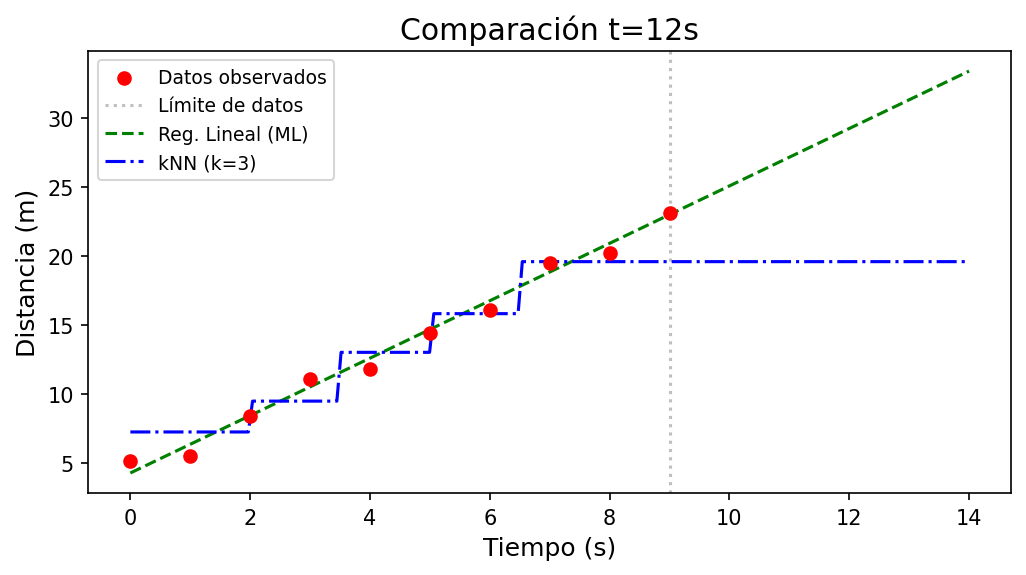

In [62]:
# Visualizamos los tres modelos en rango extendido
t_plot = np.linspace(0, 14, 200).reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, c='red', zorder=5, label='Datos observados')
plt.axvline(x=x.max(), color='gray', linestyle=':', alpha=0.5, label='Límite de datos')
#plt.plot(t_plot, bestm * t_plot + bestb, 'k-', label='Inferencia')
plt.plot(t_plot, regmodel.predict(t_plot), 'g--', label='Reg. Lineal (ML)')
plt.plot(t_plot, knnmodel.predict(t_plot), 'b-.', label='kNN (k=3)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.title('Comparación t=12s')
plt.legend(fontsize=9)
plt.tight_layout()

**Pregunta: ¿Qué le pasa a kNN en la zona t > 9? ¿Por qué? ¿Es un problema para este caso?**

**Tu respuesta:** Por definición, kNN necesita datos cercanos a un punto nuevo para poder predecir sus valores. Los datos llegan sólo hasta t = 9 y, más allá de ese rango, no tiene información con la que trabajar para que el modelo pueda predecir valores adecuadamente, dándole una validez restringida por el set de datos.



### 2d. ¿Importa el valor de k?

In [63]:
# Prueba distintos valores de k y compara el MSE en test
for k in [1, 2, 3, 5, 7]:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train.reshape(-1, 1), y_train)
    mse = np.mean((y_test - m.predict(X_test.reshape(-1, 1)))**2)
    pred_12 = m.predict([[12]])[0]
    print(f'k={k}  →  MSE test: {mse:.3f}  |  d(t = 12): {pred_12:.2f} m')

k=1  →  MSE test: 3.557  |  d(t=12): 23.10 m
k=2  →  MSE test: 0.474  |  d(t=12): 21.30 m
k=3  →  MSE test: 1.241  |  d(t=12): 19.57 m
k=5  →  MSE test: 7.017  |  d(t=12): 16.32 m
k=7  →  MSE test: 24.559  |  d(t=12): 13.17 m


**Pregunta: ¿Cuál k elegirías? ¿Qué criterio usarías para elegirlo de forma sistemática?**

**Tu respuesta:** Elegiría el k = 2, debido a que de los k probados, es el que tiene el MSE más bajo. En otros casos, también sería necesario examinar la situación que se está analizando (por ejemplo, si estamos frente a datos de un pulsar, de series temporales de campo magnético, etc) para poder hacer una elección acertada del mejor k.

## Conclusión

Completa la siguiente tabla comparando las dos estrategias:

| | Inferencia estadística | Machine Learning |
|---|---|---|
| ¿Necesita conocer el modelo físico? |Sí |No |
| ¿Entrega los parámetros del modelo? |Sí|Regresión lineal sí, kNN no.|
| ¿Puede extrapolar fuera del rango de datos? |Sí |La regresión lineal puede, kNN no|
| ¿Cómo maneja las incertezas? |Las considera para ponderar los datos|No las utiliza|
| ¿Cuándo la usarías en tu investigación? |Cuando se conoce el modelo físico|Cuando se necesita un modelo que sólo abarque el rango determinado por los datos disponibles|

**Pregunta final:** Si la relación fuera sinusoidal en vez de lineal (por ejemplo,
el movimiento de un péndulo), ¿qué estrategia funcionaría mejor?
Prueba cambiando `y = 2*x + 5 + ruido` por `y = np.sin(x) + ruido` al inicio.

**Tu respuesta:** Si los datos conocidos permitieran asumir que hay una relación sinusoidal, podría utilizarse inferencia estadística. No podría utilizarse la regresión lineal para una relación de ese tipo, pero sí kNN, con la ventaja de que no se podría extrapolar para poder inferir un modelo más allá del rango de los datos.